[2026-03-01 15:06:59] === 3銘柄ランダム AR 分析開始 ===
[2026-03-01 15:06:59] Selected: BTC, SOL, AVAX
[2026-03-01 15:06:59] 
=== Fetching BTC ===
[2026-03-01 15:06:59] GET https://api.coingecko.com/api/v3/coins/bitcoin/market_chart (attempt 1/3)
[2026-03-01 15:07:00] Fetched 2161 rows for BTC
[2026-03-01 15:07:00] [BTC] Train=1728, Test=432
[2026-03-01 15:07:00] [BTC] MSE=3.208192e-05, RMSE=5.664091e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


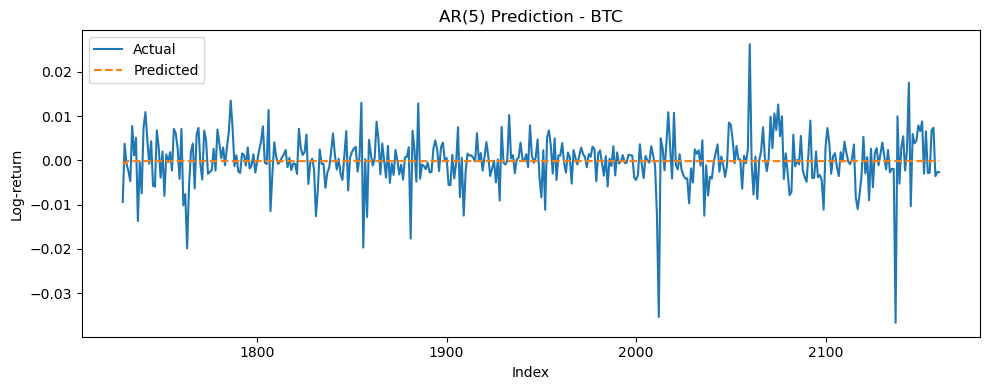

[2026-03-01 15:07:02] 
=== Fetching SOL ===
[2026-03-01 15:07:02] GET https://api.coingecko.com/api/v3/coins/solana/market_chart (attempt 1/3)
[2026-03-01 15:07:02] Fetched 2161 rows for SOL
[2026-03-01 15:07:02] [SOL] Train=1728, Test=432
[2026-03-01 15:07:02] [SOL] MSE=6.515123e-05, RMSE=8.071631e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


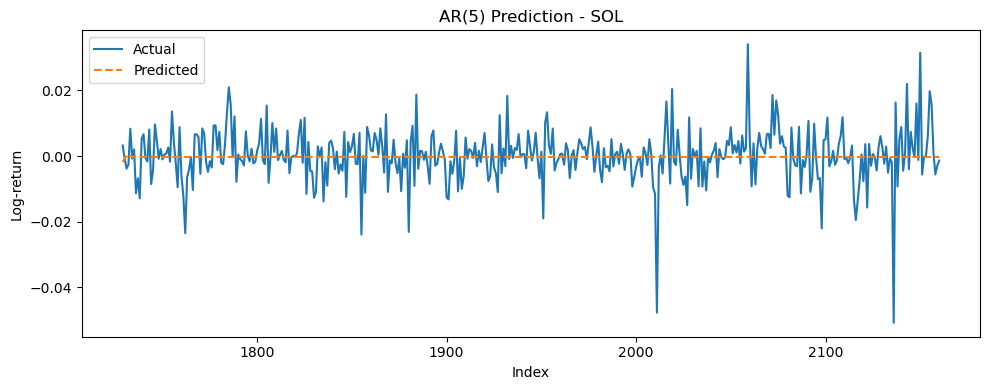

[2026-03-01 15:07:05] 
=== Fetching AVAX ===
[2026-03-01 15:07:05] GET https://api.coingecko.com/api/v3/coins/avalanche-2/market_chart (attempt 1/3)
[2026-03-01 15:07:05] Fetched 2161 rows for AVAX
[2026-03-01 15:07:05] [AVAX] Train=1728, Test=432
[2026-03-01 15:07:05] [AVAX] MSE=5.819767e-05, RMSE=7.628740e-03


c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


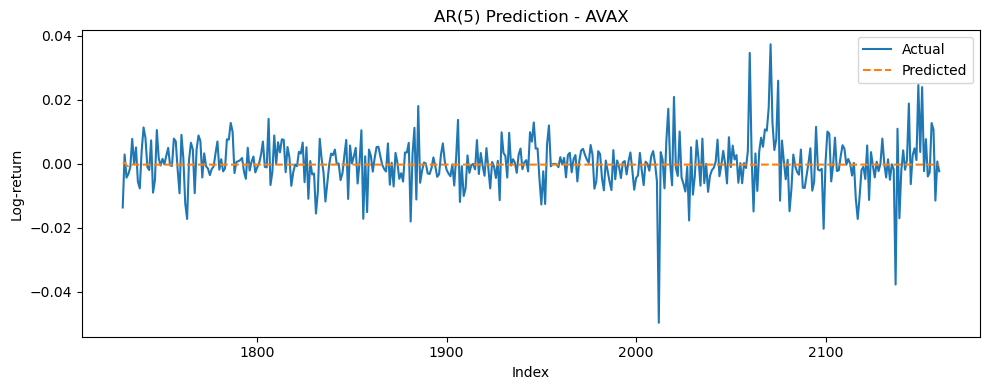



=== AR 予測精度まとめ ===
symbol      mse     rmse
   BTC 0.000032 0.005664
   SOL 0.000065 0.008072
  AVAX 0.000058 0.007629
[2026-03-01 15:07:07] === 完了 ===


In [1]:
import time
import random
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg

# ============================
# 設定
# ============================
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90

BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"
MAX_RETRIES = 3
SLEEP_ON_429 = 5
SLEEP_BETWEEN_CALLS = 2   # Rate-limit 対策


# ============================
# ログ表示（時刻付き）
# ============================
def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ============================
# API 取得関数
# ============================
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0 stable-demo"})


def fetch_market_chart(coin_id, days=90, vs="usd"):
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            log(f"GET {url} (attempt {attempt}/{MAX_RETRIES})")
            r = session.get(url, params=params, timeout=30)

            if r.status_code == 200:
                data = r.json()
                df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
                df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
                return df

            if r.status_code == 429:
                log(f"[429] Too Many Requests → Wait {SLEEP_ON_429}s")
                time.sleep(SLEEP_ON_429)
                continue

            r.raise_for_status()

        except Exception as e:
            log(f"[ERROR] {e} → 3s 待機して再試行")
            time.sleep(3)

    raise RuntimeError(f"Failed after retries: {coin_id}")


# ============================
# AR モデル適用
# ============================
def apply_ar(df, symbol, lags=5):
    df = df.sort_values("timestamp")
    df["log_price"] = np.log(df["price"])
    df["ret"] = df["log_price"].diff()
    series = df["ret"].dropna()

    train_size = int(len(series) * 0.8)
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]

    log(f"[{symbol}] Train={len(train)}, Test={len(test)}")

    model = AutoReg(train, lags=lags, old_names=False)
    res = model.fit()

    pred = res.predict(start=train_size, end=train_size + len(test) - 1)

    mse = ((test.values - pred.values) ** 2).mean()
    rmse = np.sqrt(mse)

    log(f"[{symbol}] MSE={mse:.6e}, RMSE={rmse:.6e}")

    # プロット
    plt.figure(figsize=(10, 4))
    plt.plot(test.index, test.values, label="Actual")
    plt.plot(test.index, pred.values, "--", label="Predicted")
    plt.title(f"AR({lags}) Prediction - {symbol}")
    plt.xlabel("Index")
    plt.ylabel("Log-return")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse, res


# ============================
# メイン処理
# ============================
def main():
    log("=== 3銘柄ランダム AR 分析開始 ===")

    # ランダムに3つ選ぶ
    selected = random.sample(COINS_POOL, 3)
    log(f"Selected: {', '.join(sym for _, sym in selected)}")

    results = []

    for coin_id, symbol in selected:
        log(f"\n=== Fetching {symbol} ===")
        df = fetch_market_chart(coin_id, DAYS, VS)
        log(f"Fetched {len(df)} rows for {symbol}")

        mse, rmse, model = apply_ar(df, symbol)

        results.append({
            "symbol": symbol,
            "mse": mse,
            "rmse": rmse,
            "model": model,
        })

        time.sleep(SLEEP_BETWEEN_CALLS)

    # ----------------------
    # 3銘柄の性能比較表示
    # ----------------------
    print("\n\n=== AR 予測精度まとめ ===")
    summary = pd.DataFrame(results)[["symbol", "mse", "rmse"]]
    print(summary.to_string(index=False))

    log("=== 完了 ===")


if __name__ == "__main__":
    main()